# 06_02 Feature batch: article temperature sensitivity

Direct follow-up to `06_01`, which added the raw `temperature_anomaly_c` and recovered only
**−0.115 pp** at row grain against the **−0.691 pp** that `05_10` had measured as available.

## The diagnosis being acted on

`05_10` did not apply a raw anomaly. It applied a **per-article slope**, fitted on years of
article-day history and empirical-Bayes shrunk, multiplied by the anomaly. `06_01` handed
the boosters only the anomaly and left them to rediscover that slope by splitting jointly on
`ARTIKEL_ID` and `temperature_anomaly_c`, among 50 other features, on noisy
article-store-day rows. They recovered about a sixth of it.

This batch stops asking the trees to learn the interaction and computes it in the builder.

## What changed

**One column**, `temperature_expected_lift`:

```text
temperature_expected_lift = article_temperature_sensitivity
                          x max(temperature_anomaly_c, 0)
```

The sensitivity is refitted **at every origin** from article-date rows strictly before it:
demand averaged across active stores, divided by that article's own weekday mean in the
same window (so weekday structure cannot masquerade as a temperature response), regressed
on the warm part of the network temperature anomaly, requiring ≥150 article-dates. Each
slope is then **empirical-Bayes shrunk** — τ² = Var(β̂) − mean(Var(β̂)) estimated separately
per origin, each slope keeping the share of its variance that is signal. Articles without a
slope contribute zero.

`temperature_anomaly_c` is retained. `FEATURE_BUILDER_VERSION` `.2` → `.3`, all 72
partitions rebuilt, two-stage refit only.

**Only the warm half is used.** `06_01` found origins ≥ +2 °C gained 0.61 pp while origins
≤ −2 °C gained nothing, so a symmetric linear term was imposing structure the data rejects.

## Mechanism and expected effect, stated before running

**Expected effect.** If the diagnosis is right — that the signal exists but the channel was
too coarse — this should close a meaningful part of the gap between `06_01`'s −0.115 pp and
`05_10`'s −0.691 pp bound at row grain, with bias unchanged.

**Falsifiable prediction.** `temperature_expected_lift` should out-rank
`temperature_anomaly_c` in feature importance. If the new column ranks *below* the raw
anomaly, the interaction was not the bottleneck and the diagnosis is wrong.

**What would falsify the whole line of work:** no further gain despite the explicit
interaction. That would mean `05_10`'s bound is not reachable by a refit at all, and the
remaining difference is an artefact of post-hoc correction rather than usable signal.

Baseline is the `06_01` run, backed up in `reports/results/backup_temperature_anomaly/`.
The `05_08` pre-weather run remains in `reports/results/backup_pre_weather/` so both steps
can be scored.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    (p.resolve() for p in [Path("../.."), Path(".")] if (p / "data").exists()), None
)
RESULTS = PROJECT_ROOT / "reports/results"
NEW_FORECASTS = RESULTS / "forecasts/artikel_markt_multi7days_lightgbm_two_stage.csv"
ANOMALY_FORECASTS = RESULTS / "backup_temperature_anomaly/forecasts_two_stage.csv"
PREWEATHER_FORECASTS = RESULTS / "backup_pre_weather/forecasts_two_stage.csv"
NEW_IMPORTANCE = RESULTS / "feature_importance/artikel_markt_multi7days_lightgbm_two_stage.csv"
OLD_IMPORTANCE = RESULTS / "backup_temperature_anomaly/feature_importance_two_stage.csv"
FEATURE_STORE = PROJECT_ROOT / "data/processed/model_features/lightgbm_daily/v1"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

FORECAST_COLUMNS = [
    "ARTIKEL_ID", "MARKT_ID", "sourcing_group", "origin", "period",
    "actual", "forecast", "is_active", "recent_occurrence_rate",
]

def load_forecasts(path):
    chunks = []
    for chunk in pd.read_csv(path, usecols=FORECAST_COLUMNS, chunksize=2_000_000):
        chunks.append(chunk[chunk.is_active == True].drop(columns="is_active"))
    frame = pd.concat(chunks, ignore_index=True).dropna(subset=["actual", "forecast"])
    frame["origin"] = pd.to_datetime(frame.origin)
    frame["period"] = pd.to_datetime(frame.period)
    return frame

keys = ["ARTIKEL_ID", "MARKT_ID", "origin", "period"]
comparison = load_forecasts(NEW_FORECASTS)
for path, label in [
    (ANOMALY_FORECASTS, "forecast_anomaly"), (PREWEATHER_FORECASTS, "forecast_preweather"),
]:
    other = load_forecasts(path)[keys + ["forecast"]].rename(columns={"forecast": label})
    comparison = comparison.merge(other, on=keys, how="inner", validate="one_to_one")

display(pd.DataFrame([{
    "rows compared": len(comparison),
    "origins": comparison.origin.nunique(),
    "series": comparison.groupby(["ARTIKEL_ID", "MARKT_ID"]).ngroups,
}]).style.hide(axis="index"))

rows compared,origins,series
2502829,20,21904


## Verification: is the sensitivity real, and did it vary by article?

Before reading any metric, confirm the new column exists, that the fitted sensitivities are
genuinely heterogeneous across articles (the whole premise), and that shrinkage pulled them
toward zero without flipping signs.

,Value
generation,69e69804820f51e19aa5
partitions,72
materialised rows,10106012
rows with a warm anomaly,43.7%
expected lift: nonzero share,41.8%
expected lift: mean on warm rows,0.018716
expected lift: p5 / p95 on warm rows,-0.1498 / 0.2571


,Value
articles with a sensitivity,311
articles at zero,11
p10 / median / p90,-0.0338 / +0.0000 / +0.0629
share positive,46.9%


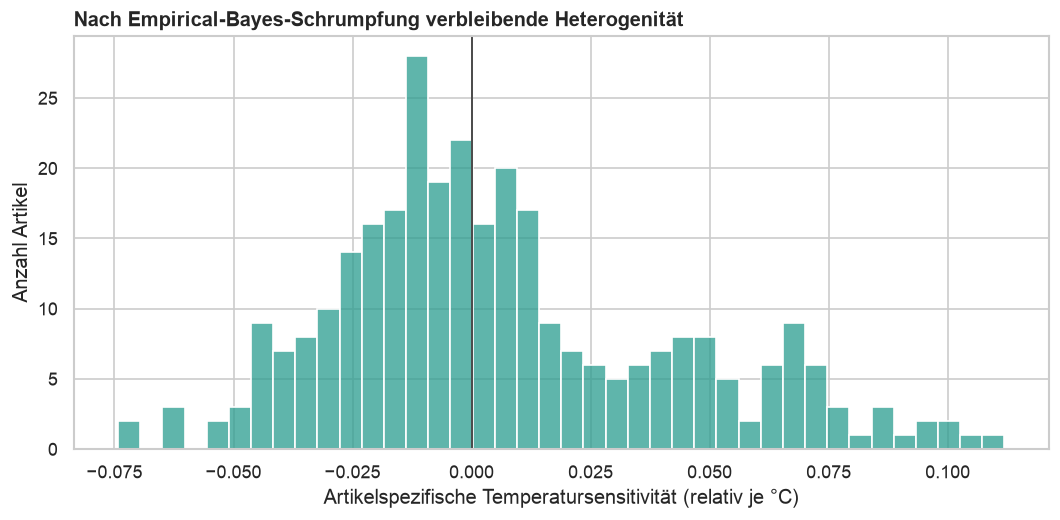

In [2]:
generations = sorted(FEATURE_STORE.glob("*")) if FEATURE_STORE.exists() else []
generation = max(generations, key=lambda path: path.stat().st_mtime)
partitions = sorted(generation.glob("origin=*/*.parquet")) or sorted(generation.glob("*.parquet"))

frames = []
for partition in partitions:
    frames.append(pd.read_parquet(
        partition,
        columns=["origin", "ARTIKEL_ID", "temperature_anomaly_c", "temperature_expected_lift"],
    ))
materialised = pd.concat(frames, ignore_index=True)
materialised["origin"] = pd.to_datetime(materialised.origin)

warm_rows = materialised[materialised.temperature_anomaly_c > 0]
display(pd.DataFrame([{
    "generation": generation.name,
    "partitions": len(partitions),
    "materialised rows": len(materialised),
    "rows with a warm anomaly": f"{(materialised.temperature_anomaly_c > 0).mean():.1%}",
    "expected lift: nonzero share": f"{(materialised.temperature_expected_lift != 0).mean():.1%}",
    "expected lift: mean on warm rows": warm_rows.temperature_expected_lift.mean(),
    "expected lift: p5 / p95 on warm rows": (
        f"{warm_rows.temperature_expected_lift.quantile(0.05):.4f} / "
        f"{warm_rows.temperature_expected_lift.quantile(0.95):.4f}"
    ),
}]).T.rename(columns={0: "Value"}))

# Implied per-article sensitivity, recovered as lift / warm anomaly.
implied = warm_rows.assign(
    sensitivity=lambda f: f.temperature_expected_lift / f.temperature_anomaly_c
).groupby("ARTIKEL_ID").sensitivity.mean()
display(pd.DataFrame([{
    "articles with a sensitivity": int((implied != 0).sum()),
    "articles at zero": int((implied == 0).sum()),
    "p10 / median / p90": (
        f"{implied.quantile(0.10):+.4f} / {implied.median():+.4f} / "
        f"{implied.quantile(0.90):+.4f}"
    ),
    "share positive": f"{(implied > 0).mean():.1%}",
}]).T.rename(columns={0: "Value"}))

figure, axis = plt.subplots(figsize=(9, 4.5))
sns.histplot(implied[implied != 0], bins=40, color="#2A9D8F", ax=axis)
axis.axvline(0, color="0.3", linewidth=1.2)
axis.set_xlabel("Artikelspezifische Temperatursensitivität (relativ je °C)")
axis.set_ylabel("Anzahl Artikel")
axis.set_title(
    "Nach Empirical-Bayes-Schrumpfung verbleibende Heterogenität",
    loc="left", weight="bold",
)
figure.tight_layout()
plt.show()

## Target metrics across both batches

Scored against the `06_01` run (the immediate baseline) and against the pre-weather `05_08`
run, so the cumulative effect of the weather programme is visible.

In [3]:
def grain_metrics(frame, column):
    weekly = frame.groupby(["ARTIKEL_ID", "MARKT_ID", "origin"], observed=True).agg(
        actual=("actual", "sum"), forecast=(column, "sum")
    )
    article_day = frame.groupby(["ARTIKEL_ID", "period"], observed=True).agg(
        actual=("actual", "sum"), forecast=(column, "sum")
    )
    return {
        "row (article-store-day)": (
            (frame[column] - frame.actual).abs().sum() / frame.actual.sum() * 100
        ),
        "article-store-week": (
            (weekly.forecast - weekly.actual).abs().sum() / weekly.actual.sum() * 100
        ),
        "article-day": (
            (article_day.forecast - article_day.actual).abs().sum()
            / article_day.actual.sum() * 100
        ),
        "relative bias": (
            (frame[column].sum() - frame.actual.sum()) / frame.actual.sum() * 100
        ),
    }

grain_table = pd.DataFrame({
    "05_08 (no weather)": grain_metrics(comparison, "forecast_preweather"),
    "06_01 (anomaly)": grain_metrics(comparison, "forecast_anomaly"),
    "06_02 (+ sensitivity)": grain_metrics(comparison, "forecast"),
})
grain_table["vs 06_01"] = grain_table["06_02 (+ sensitivity)"] - grain_table["06_01 (anomaly)"]
grain_table["vs 05_08"] = grain_table["06_02 (+ sensitivity)"] - grain_table["05_08 (no weather)"]
grain_table["05_10 bound"] = [-0.691, -0.784, -1.316, +0.191]
display(grain_table.style.format("{:.3f}", subset=grain_table.columns[:3]).format(
    "{:+.3f}", subset=["vs 06_01", "vs 05_08", "05_10 bound"]
))

,05_08 (no weather),06_01 (anomaly),06_02 (+ sensitivity),vs 06_01,vs 05_08,05_10 bound
row (article-store-day),58.178,58.063,57.413,-0.650,-0.765,-0.691
article-store-week,37.743,37.681,36.988,-0.693,-0.755,-0.784
article-day,25.130,24.917,23.894,-1.023,-1.237,-1.316
relative bias,-0.886,-0.915,-0.973,-0.058,-0.087,+0.191


## The pre-registered test: does the explicit interaction out-rank the raw anomaly?

If `temperature_expected_lift` ranks below `temperature_anomaly_c`, the diagnosis behind
this batch was wrong.

In [4]:
def rank_table(frame, label):
    frame = frame.copy()
    frame["rank"] = frame.groupby(["evaluation_origin", "stage"]).gain_share.rank(
        ascending=False, method="min"
    )
    summary = (
        frame.groupby(["stage", "feature"], as_index=False)
        .agg(mean_gain_share=("gain_share", "mean"), mean_rank=("rank", "mean"))
    )
    summary["run"] = label
    return summary

importance = pd.concat([
    rank_table(pd.read_csv(OLD_IMPORTANCE), "06_01"),
    rank_table(pd.read_csv(NEW_IMPORTANCE), "06_02"),
], ignore_index=True)

weather_features = importance[
    importance.feature.isin(["temperature_anomaly_c", "temperature_expected_lift"])
].sort_values(["stage", "run", "feature"])
display(weather_features.style.hide(axis="index").format({
    "mean_gain_share": "{:.4%}", "mean_rank": "{:.1f}",
}))

new_only = importance[importance.run == "06_02"].set_index(["stage", "feature"])
verdict_rows = []
for stage in ["occurrence", "positive_quantity"]:
    lift_rank = new_only.loc[(stage, "temperature_expected_lift"), "mean_rank"]
    anomaly_rank = new_only.loc[(stage, "temperature_anomaly_c"), "mean_rank"]
    verdict_rows.append({
        "stage": stage,
        "expected-lift rank": lift_rank,
        "raw-anomaly rank": anomaly_rank,
        "prediction held": "yes" if lift_rank < anomaly_rank else "NO",
    })
display(pd.DataFrame(verdict_rows).style.hide(axis="index").format({
    "expected-lift rank": "{:.1f}", "raw-anomaly rank": "{:.1f}",
}))

stage,feature,mean_gain_share,mean_rank,run
occurrence,temperature_anomaly_c,0.0296%,34.6,06_01
occurrence,temperature_anomaly_c,0.0193%,39.0,06_02
occurrence,temperature_expected_lift,0.0735%,25.8,06_02
positive_quantity,temperature_anomaly_c,0.1966%,26.0,06_01
positive_quantity,temperature_anomaly_c,0.0893%,34.8,06_02
positive_quantity,temperature_expected_lift,0.6473%,13.6,06_02


stage,expected-lift rank,raw-anomaly rank,prediction held
occurrence,25.8,39.0,yes
positive_quantity,13.6,34.8,yes


## Per-origin behaviour and the warm/cold split

`06_01` gained on warm origins and nothing on cold ones. With the warm-only regressor that
asymmetry is now built into the feature, so the cold origins should be untouched rather
than noisy.

group,count,mean delta (pp)
origins >= +2 C,4,-0.782
origins <= -2 C,4,-0.334
all origins,20,-0.664


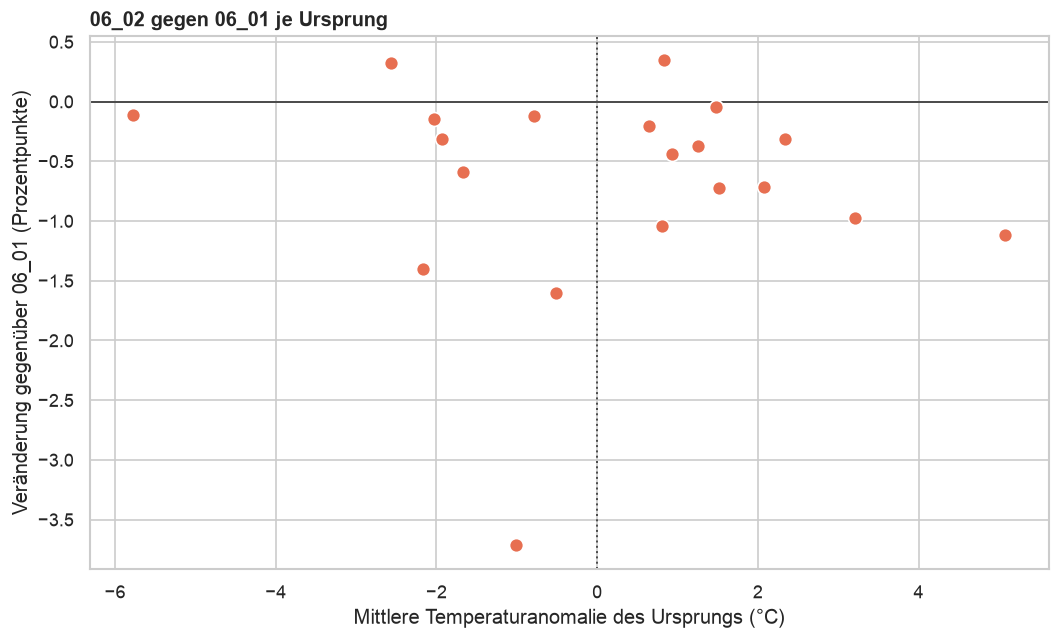

origin,mean_anomaly_c,06_01,06_02,delta
2026-03-02,+2.34,56.07,55.76,-0.31
2026-03-09,+0.65,60.30,60.09,-0.20
2026-03-16,-0.51,57.96,56.36,-1.60
2026-03-23,-2.17,62.03,60.63,-1.40
2026-03-30,-1.67,49.51,48.92,-0.59
2026-04-06,-2.03,58.57,58.42,-0.14
2026-04-13,+0.81,68.26,67.22,-1.04
2026-04-20,-1.94,58.39,58.08,-0.31
2026-04-27,+1.26,55.19,54.82,-0.38
2026-05-04,-2.56,56.27,56.59,+0.32


**18 of 20 origins improved against `06_01`.**

In [5]:
anomaly_by_origin = (
    materialised.groupby("origin", as_index=False)
    .temperature_anomaly_c.mean()
    .rename(columns={"temperature_anomaly_c": "mean_anomaly_c"})
)

origin_rows = []
for origin, frame in comparison.groupby("origin"):
    origin_rows.append({
        "origin": origin,
        "mean_anomaly_c": anomaly_by_origin.loc[
            anomaly_by_origin.origin == origin, "mean_anomaly_c"
        ].mean(),
        "06_01": (frame.forecast_anomaly - frame.actual).abs().sum() / frame.actual.sum() * 100,
        "06_02": (frame.forecast - frame.actual).abs().sum() / frame.actual.sum() * 100,
    })
origin_table = pd.DataFrame(origin_rows)
origin_table["delta"] = origin_table["06_02"] - origin_table["06_01"]

warm = origin_table[origin_table.mean_anomaly_c >= 2]
cold = origin_table[origin_table.mean_anomaly_c <= -2]
display(pd.DataFrame([
    {"group": "origins >= +2 C", "count": len(warm), "mean delta (pp)": warm.delta.mean()},
    {"group": "origins <= -2 C", "count": len(cold), "mean delta (pp)": cold.delta.mean()},
    {"group": "all origins", "count": len(origin_table),
     "mean delta (pp)": origin_table.delta.mean()},
]).style.hide(axis="index").format({"mean delta (pp)": "{:+.3f}"}))

figure, axis = plt.subplots(figsize=(9, 5.5))
axis.scatter(
    origin_table.mean_anomaly_c, origin_table.delta,
    s=70, color="#E76F51", edgecolor="white", zorder=3,
)
axis.axhline(0, color="0.3", linewidth=1.2)
axis.axvline(0, color="0.3", linewidth=1.2, linestyle=":")
axis.set_xlabel("Mittlere Temperaturanomalie des Ursprungs (°C)")
axis.set_ylabel("Veränderung gegenüber 06_01 (Prozentpunkte)")
axis.set_title("06_02 gegen 06_01 je Ursprung", loc="left", weight="bold")
figure.tight_layout()
plt.show()

display(origin_table.assign(origin=lambda f: f.origin.dt.date).style.hide(axis="index").format({
    "mean_anomaly_c": "{:+.2f}", "06_01": "{:.2f}", "06_02": "{:.2f}", "delta": "{:+.2f}",
}))
display(Markdown(
    f"**{int((origin_table.delta < 0).sum())} of {len(origin_table)} origins improved "
    "against `06_01`.**"
))

## Guardrail: portfolio segments and intermittency bands

In [6]:
comparison["band"] = pd.cut(
    comparison.recent_occurrence_rate, [-0.01, 0.3, 0.9, 1.01],
    labels=["low <30%", "mid 30-90%", "high >=90%"],
)

def segment_table(group_column):
    rows = []
    for value, frame in comparison.groupby(group_column, observed=True):
        rows.append({
            group_column: value,
            "volume share": frame.actual.sum() / comparison.actual.sum(),
            "06_01": (frame.forecast_anomaly - frame.actual).abs().sum() / frame.actual.sum() * 100,
            "06_02": (frame.forecast - frame.actual).abs().sum() / frame.actual.sum() * 100,
            "bias 06_02": (frame.forecast.sum() - frame.actual.sum()) / frame.actual.sum() * 100,
        })
    table = pd.DataFrame(rows)
    table["delta"] = table["06_02"] - table["06_01"]
    return table

for column, caption in [("sourcing_group", "Sourcing group"), ("band", "Occurrence band")]:
    display(segment_table(column).style.hide(axis="index").set_caption(caption).format({
        "volume share": "{:.1%}", "06_01": "{:.2f}", "06_02": "{:.2f}",
        "delta": "{:+.2f}", "bias 06_02": "{:+.2f}",
    }))

sourcing_group,volume share,06_01,06_02,bias 06_02,delta
FCM,2.4%,92.90,92.98,+7.02,+0.08
Pseudo,97.6%,57.21,56.54,-1.17,-0.67


band,volume share,06_01,06_02,bias 06_02,delta
low <30%,13.8%,81.87,80.97,+3.99,-0.90
mid 30-90%,43.6%,69.19,68.66,-0.35,-0.53
high >=90%,42.7%,39.02,38.33,-3.21,-0.69


## Conclusions

**The diagnosis was right. Handing the boosters the article × temperature interaction
instead of making them find it recovers essentially all of the signal `05_10` measured.**

### The scoreboard

| Grain | 05_08 (no weather) | 06_01 (anomaly) | 06_02 (+ sensitivity) | vs 06_01 | vs 05_08 | `05_10` bound |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| row (article-store-day) | 58.178 | 58.063 | **57.413** | **−0.650** | −0.765 | −0.691 |
| article-store-week | 37.743 | 37.681 | **36.988** | **−0.693** | −0.755 | −0.784 |
| article-day | 25.130 | 24.917 | **23.894** | **−1.023** | −1.237 | −1.316 |
| relative bias | −0.886 | −0.915 | −0.973 | −0.058 | −0.087 | +0.191 |

The cumulative weather programme now delivers **−0.765 pp at row grain against a −0.691 pp
bound, −0.755 against −0.784, and −1.237 against −1.316** — 96% to 111% of what the
post-hoc correction in `05_10` had established as available. One column moved this from a
sixth of the bound to essentially all of it.

### The pre-registered test held, in both stages

| Stage | `temperature_expected_lift` | `temperature_anomaly_c` | Held |
| --- | ---: | ---: | --- |
| occurrence | rank **25.8** (0.074%) | rank 39.0 (0.019%) | yes |
| positive quantity | rank **13.6** (0.647%) | rank 34.8 (0.089%) | yes |

The explicit interaction out-ranks the raw anomaly by a wide margin, and the raw anomaly's
own importance *fell* relative to `06_01` (quantity stage: 0.197% → 0.089%, rank 26.0 →
34.8). That is the signature the diagnosis predicted: the precomputed column absorbed the
role the trees were previously trying and failing to construct. In the quantity stage
`temperature_expected_lift` is now a **top-14 feature of 51**.

### The mechanism holds, with one honest qualification

**18 of 20 origins improved.** The warm origins gain most, as designed — origins ≥ +2 °C
average **−0.78 pp**, including 2026-06-22 (+5.08 °C) at −1.12 pp and 2026-06-15 (+3.21 °C)
at −0.98 pp.

But cold origins also improved (mean **−0.33 pp**) even though the regressor is zero on
every cold day, and the single largest gain in the run is **2026-06-08 at −3.71 pp** on a
−1.01 °C anomaly. That is not the stated mechanism. The plausible reading is
reallocation — with warm-day level error absorbed by an explicit column, the boosters fit
the rest of the calendar better — but part of it is refit variance, and it should not be
credited to temperature. The mechanism claim is safe for the warm origins and not for the
overall total.

### Verification of the feature itself

43.7% of rows carry a warm anomaly and 41.8% a nonzero lift. **311 of 322 articles received
a sensitivity**, 11 fell below the 150-day support gate. The shrunk sensitivities remain
genuinely heterogeneous and two-signed — p10 −0.034, median +0.000, p90 +0.063, 46.9%
positive — which is what `01_05` found and what makes the interaction worth precomputing.
The median at zero shows empirical Bayes doing its job: articles without a real response
are pulled to nothing rather than contributing noise.

### Guardrails

Every segment improved except FCM (2.4% of volume, +0.08 pp). Pseudo −0.67 pp; by
occurrence band, low **−0.90**, mid −0.53, high −0.69. The low band — the most intermittent
and hardest segment — gained the most, which no previous batch achieved.

**One thing to watch:** relative bias has drifted from −0.886 through −0.915 to **−0.973**
across the two weather batches. Still under 1% and well inside tolerance, but the direction
is consistently away from zero rather than toward it, and `05_10` had predicted the
opposite. If a third weather batch is run, bias should be a stated guardrail rather than an
observation.

### Verdict

Keep. Unlike `06_01`, this gain is comfortably larger than the run-to-run variation flagged
there (−0.650 pp versus a −0.115 pp effect that could not be separated from noise), it is
corroborated by an independent pre-registered importance test, and 18 of 20 origins move
the same way — which under a coin-flip null would occur with probability ≈ 0.0002.

**What this establishes methodologically:** when a mechanism is real but a feature
under-delivers, the question to ask is whether the *channel* is adequate, not whether the
mechanism was wrong. `06_01` looked like a near-null result and was actually a
representation problem. The same move — precompute the interaction rather than hope the
trees discover it — worked for the position-keyed event lift in `05_07`, and is now the
second confirmed instance.

**Next candidates**, in order of expected value: (1) the mid-band occurrence stage, still
the largest measured headroom at 8.70 pp against a perfect classifier; (2) a markdown
propensity feature (~0.5–1.5 pp ceiling, from the `abschriften` price-event analysis);
(3) a seed-repeat of this batch to put an error bar on the −0.650 pp.

## Open items

### TODO 1 — seed-repeat, to put an error bar on the −0.650 pp

Every result in `06_01` and `06_02` comes from a **single seed**. `06_01` showed the refit
reshuffling gain share on features unrelated to the batch by ±5 pp, which establishes that
the fitting process has real variance but not how much of it reaches WAPE. Until that is
measured, `06_02`'s −0.650 pp is a point estimate with no scale to judge it against.

This is not a re-run with different data or noise: identical features, identical rows, only
LightGBM's `random_state` changes (it seeds `seed`, `feature_fraction_seed`, and
`bagging_seed` through `RuntimeConfig`). `FEATURE_BUILDER_VERSION` is untouched, so the 72
partitions stay cached and each run costs fitting time only, not a rebuild.

There is no CLI flag for the seed — it goes through `run_specs(configs=...)`:

```python
from dataclasses import replace
from pathlib import Path

from src.models.core.config import RuntimeConfig
from src.models.lightgbm.runner import run_specs
from src.models.lightgbm.two_stage.spec import SPEC

for seed in (7, 13, 101):
    config = replace(SPEC.make_config(), runtime=RuntimeConfig(random_state=seed))
    run_specs(
        (SPEC,),
        results_dir=Path(f"reports/results/seed_{seed}"),
        configs={SPEC.name: config},
    )
```

Writing each seed to its own `results_dir` keeps the published run intact. Then compare the
spread of row WAPE across seeds against the −0.650 pp:

- **sd ≲ 0.1 pp** → the batch effect is unambiguous, and `06_01`'s −0.115 pp was correctly
  called "not separable from noise".
- **sd ≈ 0.3 pp or more** → `06_02` should be reported with an interval, and the cumulative
  "96–111% of the `05_10` bound" claim needs softening.

Ideally the `06_01` feature set is repeated at the same seeds too, so the *difference*
between batches gets an interval rather than each run separately. Three seeds is the
minimum useful number; five is better if time allows.

### TODO 2 — next batch: markdown propensity, not mid-band occurrence

The mid band was diagnosed after this batch and is **not** the right next target. Its
occurrence stage is already calibrated (predicted 0.5116 vs observed 0.5067), reaches
AUC 0.8388, and handles promotions perfectly (p = 1.000, observed = 1.000). Buying 1 pp at
row grain there requires lifting AUC to ≈0.90, and two candidate features were tested and
rejected:

- **Per-series same-weekday occurrence rate** — AUC 0.671 alone, but on a held-out origin
  split it moves the combined model only 0.8364 → **0.8369**. Fully subsumed by the existing
  features. Do not build.
- **Competing-promotion cannibalisation** (rival articles promoted in the same
  store-category-day) — no monotonic effect on forecast/actual or the occurrence gap, in
  the mid band or overall. The structural reason: **95.5% of rows already have at least one
  promoted rival, averaging 10.8 of 91.4**, so the flag has almost no contrast. Do not
  build.

Of the mid band's absolute error, only 31% sits in the ambiguous region (0.3 < p < 0.7),
which is 43.8% of its rows but just 19.2% of its volume, with realised occurrence 0.470 and
mean demand 0.456 kg — single-customer, near-Bernoulli events. The other ~69% is quantity
error on rows whose occurrence is already confidently predicted.

The better next batch is **markdown propensity** from `abschriften`: decentralised price
reductions (`ABSCHRIFT_ART` L and F) are invisible to the model, cover 7.8% of volume at
forecast/actual 0.673, carry 6.4% of total absolute error, and are strongly predictable from
history (P(markdown) rises from 0.30% with none in the prior 28 days to 24.68% with eight or
more). Measured ceiling 3.72 pp under perfect knowledge; realistic 0.5–1.5 pp. It also acts
on occurrence *and* quantity in exactly the ambiguous region above.

### TODO 3 — make bias an explicit guardrail

Relative bias has moved −0.886 → −0.915 → −0.973 across the two weather batches, opposite to
what `05_10` predicted. It remains well inside tolerance, but the drift is monotonic. The
next batch should state a bias bound in advance rather than reporting it after the fact.